In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.dpi'] = 110
np.random.seed(0)

In [ ]:
# Caricamento e pulizia 
#twitter_it_leaders  = pd.read_parquet("twitter_it_leaders.parquet")
twitter_it_tweets   = pd.read_pickle("twitter_it_tweets.pkl")
twitter_it_retweets = pd.read_pickle("twitter_it_retweets.pkl")
twitter_it_leaders = pd.read_csv("leaders_labeled.csv")

twitter_it_leaders.columns = ["reference_author"] + list(twitter_it_leaders.columns[1:])

# Filtra leader con cluster definito (dataset di ema, non tutti ce l'hanno definito, solo 125)
leaders_clean = twitter_it_leaders[twitter_it_leaders['pageCategory']=='POLITICS']


In [53]:

leader_ids    = leaders_clean["reference_author"]
# Retweet utente -> leader (esclusi leader -> leader

In [56]:
leader_ids = leaders_clean["reference_author"].astype(str)

In [58]:
rt = twitter_it_retweets.copy()
rt = rt[rt["reference_author"] != rt["referenced_author"]]

In [59]:
rt

,reference_time,reference_author,reference_id,reference_type,referenced_id,referenced_author,agreement,agreementAnnotated,training_set
0,2019/02/22 00:00:01,1000000069729386496,1098990549988724742,retweeted,1098943038448173056,417469423,1,<NA>,<NA>
1,2019/11/06 00:00:01,1000001291945500672,1192118568592322565,retweeted,1191663175416066049,1156217286136598529,1,<NA>,<NA>
2,2020/08/14 00:00:01,1000001291945500672,1294336981565153282,retweeted,1294190815615614977,269313122,1,<NA>,<NA>
3,2019/01/06 00:00:01,1000001613589811202,1081938701754732544,retweeted,1081889367738732544,390016416,1,<NA>,<NA>
4,2021/03/10 00:00:01,1000001752077254656,1369611389615022081,retweeted,1369355593547460609,3157167368,1,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...
36299747,2018/08/24 00:00:01,999293382655598592,1032983366075703296,retweeted,NaN,NaN,1,<NA>,<NA>
36299748,2018/08/26 00:00:01,999358789219487744,1033819003108646918,retweeted,NaN,NaN,1,<NA>,<NA>
36299749,2020/01/24 00:00:01,999596295525453824,1220721908766986247,retweeted,NaN,NaN,1,<NA>,<NA>
36299750,2018/12/08 00:00:01,999673005830701057,1071445578394013697,retweeted,NaN,NaN,1,<NA>,<NA>


In [60]:
# Uniformazione dei tipi per i leader
leaders_clean["reference_author"] = leaders_clean["reference_author"].astype(str)

# Uniformazione dei tipi per i retweet
twitter_it_retweets["referenced_author"] = twitter_it_retweets["referenced_author"].astype(str)
twitter_it_retweets["reference_author"] = twitter_it_retweets["reference_author"].astype(str)

/var/folders/hn/4m0vzvzx5wq3dtqt4b_s6mc40000gn/T/ipykernel_99134/2841540049.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  leaders_clean["reference_author"] = leaders_clean["reference_author"].astype(str)


In [61]:
rt = rt.merge(
leaders_clean[["reference_author", "cluster_all"]].rename(
columns={"reference_author": "referenced_author", "cluster_all": "leader_cluster"}
),
on="referenced_author", how="left"
)

In [64]:
rt = rt[rt['leader_cluster'].notna()]

In [67]:
# Tempo come ema 
if "referenced_time" not in rt.columns:
    tweets_subset = (twitter_it_tweets[["reference_time", "reference_id"]]
                     .drop_duplicates()
                     .rename(columns={"reference_id": "referenced_id",
                                      "reference_time": "ref_time_from_tweets"}))
    rt = rt.merge(tweets_subset, on="referenced_id", how="left")
    rt["referenced_time"] = pd.to_datetime(rt["ref_time_from_tweets"], utc=True)
else:
    rt["referenced_time"] = pd.to_datetime(rt["referenced_time"], utc=True)

rt["month_year"] = rt["referenced_time"].dt.to_period("M").astype(str)

K = leaders_clean["cluster_all"].nunique()
clusters = sorted(leaders_clean["cluster_all"].unique())
print(f"K = {K} cluster: {clusters}")
print(f"Numero leader: {len(leaders_clean)}")
print(f"Numero utenti unici: {rt['reference_author'].nunique():,}")
print(f"Numero retweet utente->leader: {len(rt):,}")
print(f"Periodo: {rt['referenced_time'].min()} -> {rt['referenced_time'].max()}")

/var/folders/hn/4m0vzvzx5wq3dtqt4b_s6mc40000gn/T/ipykernel_99134/1474190239.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  rt["month_year"] = rt["referenced_time"].dt.to_period("M").astype(str)


K = 3 cluster: [np.int64(0), np.int64(1), np.int64(2)]
Numero leader: 37
Numero utenti unici: 449,982
Numero retweet utente->leader: 8,619,899
Periodo: 2017-12-31 17:06:41+00:00 -> 2022-12-31 23:19:02+00:00


# 1. GEOMETRIA? 

In [68]:
# Costruzione dei vettori opinione (intero periodo)
N_MIN = 5  # filtro minimo: almeno 5 retweet a leader nel periodo

user_cluster_counts = (rt.groupby(["reference_author", "leader_cluster"])
                         .size().unstack(fill_value=0))

user_totals = user_cluster_counts.sum(axis=1)
active_users = user_totals[user_totals >= N_MIN].index
user_cluster_counts = user_cluster_counts.loc[active_users]

# Normalizzazione sul simplesso
X = user_cluster_counts.div(user_cluster_counts.sum(axis=1), axis=0)

print(f"Utenti attivi (>= {N_MIN} retweet): {len(X):,}")
print(f"Forma matrice opinioni: {X.shape}")
print(f"Verifica simplesso: somma media riga = {X.sum(axis=1).mean():.6f} (deve essere 1)")
print("Esempio di vettore opinione (primi 3 utenti):")
print(X.head(3))

Utenti attivi (>= 5 retweet): 114,252
Forma matrice opinioni: (114252, 3)
Verifica simplesso: somma media riga = 1.000000 (deve essere 1)
Esempio di vettore opinione (primi 3 utenti):
leader_cluster       0.0  1.0  2.0
reference_author                  
1000002007531388930  0.0  0.0  1.0
100000213            0.0  0.0  1.0
1000007406892601344  0.2  0.8  0.0


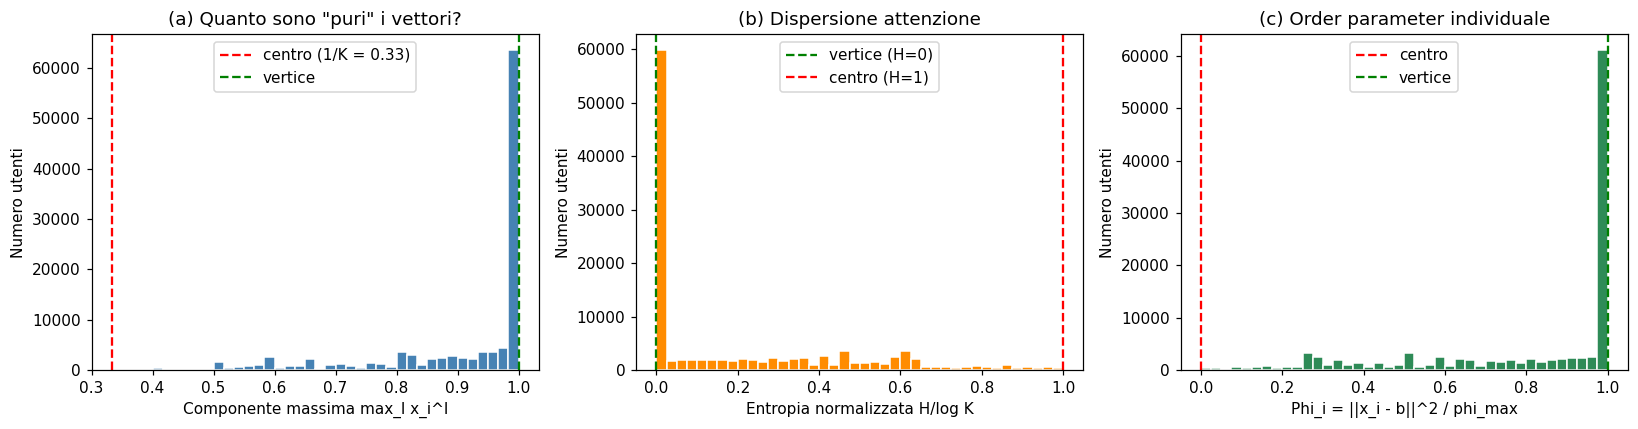

Mediana componente massima: 1.000
% utenti con max_comp > 0.8: 80.4%
% utenti con max_comp < 0.4: 0.2%
Phi medio della popolazione: 0.806
  (Phi=1 polarizzato, Phi=1/(K+1)~0.250 esplorazione, Phi=0 consensus)


In [69]:
# VEDIAMO LA GEOMETRIA DEI VETTORI OPINIONE SUL SIMPLESSO

def shannon_norm(p, K=K):
    p = p[p > 0]
    if len(p) == 0:
        return 0.0
    return float(-np.sum(p * np.log(p)) / np.log(K))

# (a) componente massima del vettore di opinione
max_comp = X.max(axis=1)

# (b) entropia normalizzata
H_norm = X.apply(lambda r: shannon_norm(r.values), axis=1)

# (c) distanza dal baricentro (order parameter individuale)
b = np.ones(K) / K
phi_max = (K - 1) / K
dist_from_center = np.sum((X.values - b)**2, axis=1) / phi_max

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(max_comp, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(1/K, color='red', ls='--', label=f'centro (1/K = {1/K:.2f})')
axes[0].axvline(1.0, color='green', ls='--', label='vertice')
axes[0].set_xlabel('Componente massima max_l x_i^l')
axes[0].set_ylabel('Numero utenti')
axes[0].set_title('(a) Quanto sono "puri" i vettori?')
axes[0].legend()

axes[1].hist(H_norm, bins=40, color='darkorange', edgecolor='white')
axes[1].axvline(0, color='green', ls='--', label='vertice (H=0)')
axes[1].axvline(1, color='red', ls='--', label='centro (H=1)')
axes[1].set_xlabel('Entropia normalizzata H/log K')
axes[1].set_ylabel('Numero utenti')
axes[1].set_title('(b) ?')

axes[2].hist(dist_from_center, bins=40, color='seagreen', edgecolor='white')
axes[2].axvline(0, color='red', ls='--', label='centro')
axes[2].axvline(1, color='green', ls='--', label='vertice')
axes[2].set_xlabel('Phi_i = ||x_i - b||^2 / phi_max')
axes[2].set_ylabel('Numero utenti')
axes[2].set_title('(c) Order parameter individuale')
axes[2].legend()

plt.tight_layout()
plt.savefig('fig1_simplex_geometry.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Mediana componente massima: {max_comp.median():.3f}")
print(f"% utenti con max_comp > 0.8: {(max_comp > 0.8).mean()*100:.1f}%")
print(f"% utenti con max_comp < 0.4: {(max_comp < 0.4).mean()*100:.1f}%")
print(f"Phi medio della popolazione: {dist_from_center.mean():.3f}")
print(f"  (Phi=1 polarizzato, Phi=1/(K+1)~{1/(K+1):.3f} esplorazione, Phi=0 consensus)")


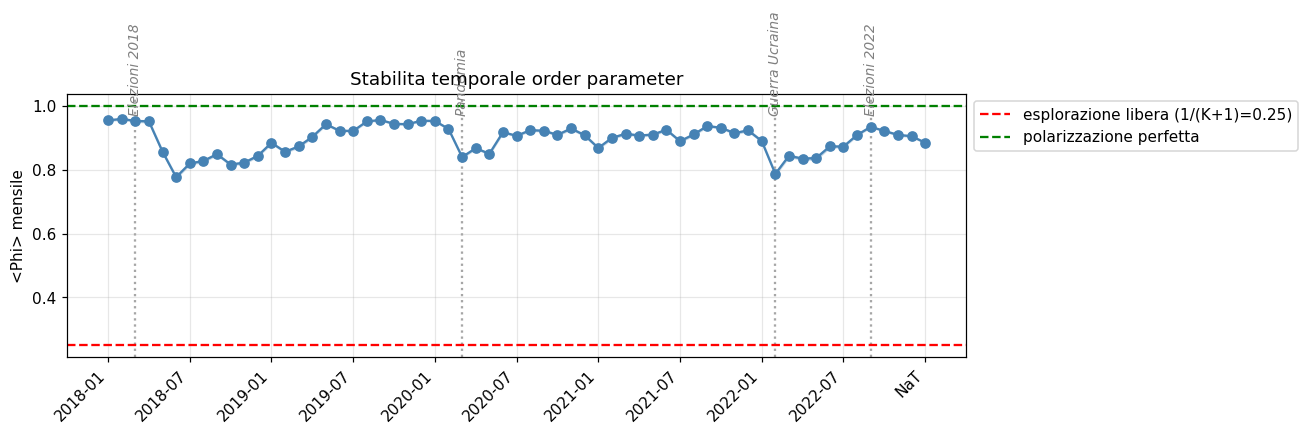

In [70]:
# Stabilita' temporale: Phi aggregato per mese
monthly_X = (rt.groupby(["reference_author", "month_year", "leader_cluster"])
               .size().unstack(fill_value=0))
monthly_totals = monthly_X.sum(axis=1)
monthly_X = monthly_X[monthly_totals >= 3]
monthly_X = monthly_X.div(monthly_X.sum(axis=1), axis=0)

phi_monthly = (monthly_X.sub(b, axis=1).pow(2).sum(axis=1) / phi_max)
phi_per_month = phi_monthly.groupby(level='month_year').agg(['mean', 'std', 'count']).sort_index()


fig, ax = plt.subplots(figsize=(12, 4))
# Convert index to list for easier position lookup
month_index_list = list(phi_per_month.index.astype(str))

ax.plot(range(len(phi_per_month)), phi_per_month['mean'], 'o-', color='steelblue', zorder=3)
ax.fill_between(range(len(phi_per_month)),
                phi_per_month['mean'] - phi_per_month['std']/np.sqrt(phi_per_month['count']),
                phi_per_month['mean'] + phi_per_month['std']/np.sqrt(phi_per_month['count']),
                alpha=0.25, color='steelblue')

# --- ADDING EVENTS ---
events = {
    '2018-03': 'Elezioni 2018',
    '2020-03': 'Pandemia',
    '2022-02': 'Guerra Ucraina',
    '2022-09': 'Elezioni 2022',
}

for date, label in events.items():
    if date in month_index_list:
        idx = month_index_list.index(date)
        ax.axvline(x=idx, color='gray', linestyle=':', alpha=0.7, zorder=1)
        # Position label at the top of the plot
        ax.text(idx, ax.get_ylim()[1], label, rotation=90, 
                verticalalignment='bottom', horizontalalignment='center',
                fontsize=9, color='gray', style='italic')

# Reference lines
ax.axhline(1/(K+1), color='red', ls='--', label=f'esplorazione libera (1/(K+1)={1/(K+1):.2f})')
ax.axhline(1.0, color='green', ls='--', label='polarizzazione perfetta')

# Formatting
step = max(1, len(phi_per_month)//10)
ax.set_xticks(range(0, len(phi_per_month), step))
ax.set_xticklabels(month_index_list[::step], rotation=45, ha='right')
ax.set_ylabel('<Phi> mensile')
ax.set_title('Stabilita temporale order parameter')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Moved legend to avoid overlap
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig1b_phi_temporal.png', dpi=120, bbox_inches='tight')
plt.show()

# OVERLAPS

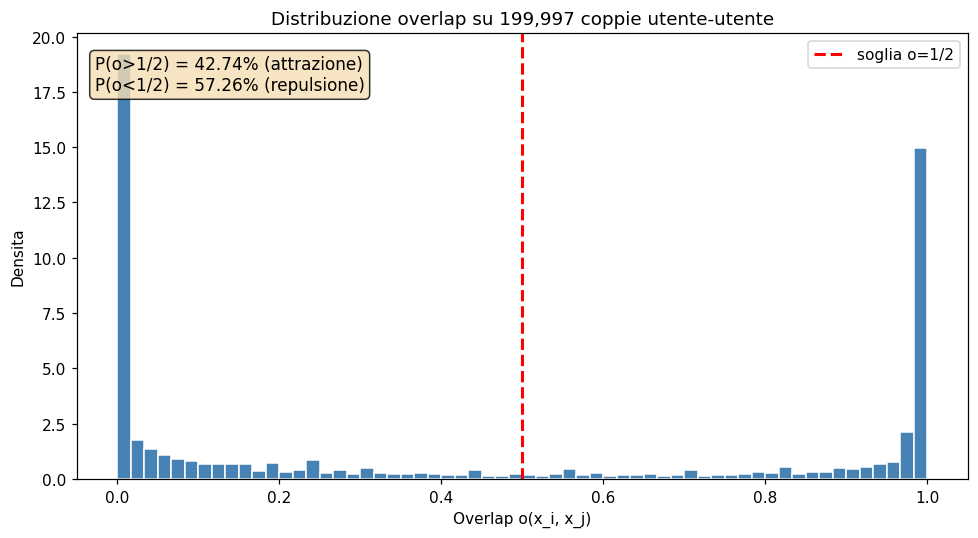

Overlap medio: 0.440
Mediana: 0.243
% coppie o > 0.5: 42.7%
% coppie o < 0.5: 57.3%


In [73]:
# Overlap empirico tra coppie di utenti (random sampling per scalabilita)
X_arr = X.values
N_users = len(X_arr)
N_PAIRS = 200_000

rng = np.random.default_rng(42)
i_idx = rng.integers(0, N_users, N_PAIRS)
j_idx = rng.integers(0, N_users, N_PAIRS)
mask = i_idx != j_idx
i_idx, j_idx = i_idx[mask], j_idx[mask]

norms = np.linalg.norm(X_arr, axis=1, keepdims=True)
Xn = X_arr / (norms + 1e-15)
overlaps = np.sum(Xn[i_idx] * Xn[j_idx], axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(overlaps, bins=60, color='steelblue', edgecolor='white', density=True)
ax.axvline(0.5, color='red', ls='--', lw=2, label='soglia o=1/2')
ax.set_xlabel('Overlap o(x_i, x_j)')
ax.set_ylabel('Densita')
ax.set_title(f'Distribuzione overlap su {len(overlaps):,} coppie utente-utente')
ax.legend()

frac_above = (overlaps > 0.5).mean()
frac_below = (overlaps < 0.5).mean()
ax.text(0.02, 0.95,
        f'P(o>1/2) = {frac_above:.2%} (attrazione)\nP(o<1/2) = {frac_below:.2%} (repulsione)',
        transform=ax.transAxes, va='top', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.tight_layout()
plt.savefig('fig2_overlap_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Overlap medio: {overlaps.mean():.3f}")
print(f"Mediana: {np.median(overlaps):.3f}")
print(f"% coppie o > 0.5: {frac_above*100:.1f}%")
print(f"% coppie o < 0.5: {frac_below*100:.1f}%")


2018: 28,409 utenti attivi
2020: 38,243 utenti attivi
2022: 38,050 utenti attivi


/var/folders/hn/4m0vzvzx5wq3dtqt4b_s6mc40000gn/T/ipykernel_99134/571522003.py:40: RuntimeWarning: divide by zero encountered in matmul
  return X_arr @ tri_vertices
/var/folders/hn/4m0vzvzx5wq3dtqt4b_s6mc40000gn/T/ipykernel_99134/571522003.py:40: RuntimeWarning: overflow encountered in matmul
  return X_arr @ tri_vertices
/var/folders/hn/4m0vzvzx5wq3dtqt4b_s6mc40000gn/T/ipykernel_99134/571522003.py:40: RuntimeWarning: invalid value encountered in matmul
  return X_arr @ tri_vertices


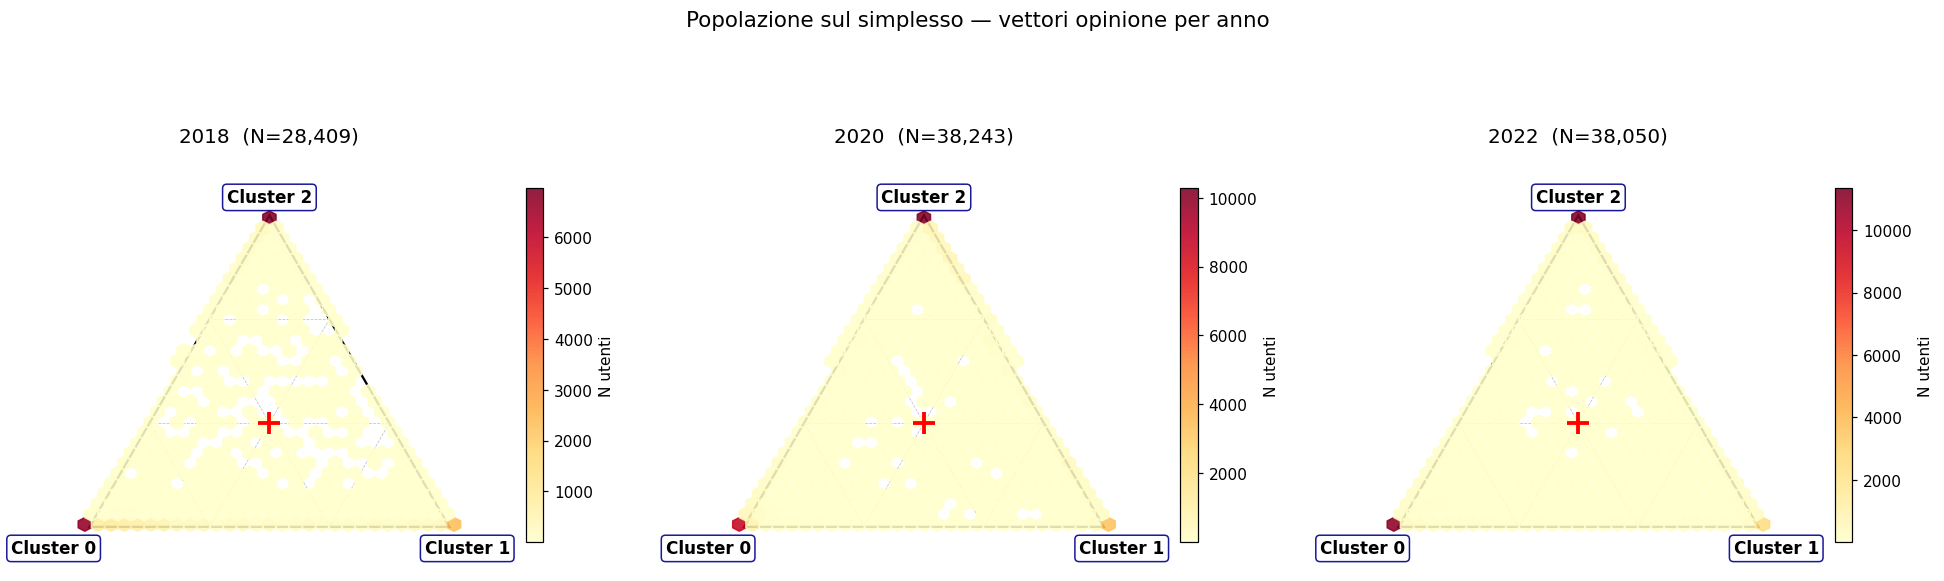

In [89]:
# ---------------------------------------------------------------
# Ternary plots: population opinion vectors per year (2018/2020/2022)
# ---------------------------------------------------------------
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection

YEARS   = [2018, 2020, 2022]
N_MIN_Y = 5   # min retweet per user within the year

# --- Build per-year opinion matrices ---
def build_year_opinion(rt, year, n_min=N_MIN_Y):
    mask = rt["referenced_time"].dt.year == year
    rt_y = rt[mask]
    counts = (rt_y.groupby(["reference_author", "leader_cluster"])
                   .size().unstack(fill_value=0))
    # ensure all 3 cluster columns are present
    for c in clusters:
        if c not in counts.columns:
            counts[c] = 0
    counts = counts[sorted(counts.columns)]
    totals = counts.sum(axis=1)
    counts = counts[totals >= n_min]
    X_y = counts.div(counts.sum(axis=1), axis=0)
    return X_y

X_years = {y: build_year_opinion(rt, y) for y in YEARS}
for y, Xy in X_years.items():
    print(f"{y}: {len(Xy):,} utenti attivi")

# --- Ternary projection (equilateral triangle, K=3) ---
# vertices: cluster 0 -> bottom-left, cluster 1 -> bottom-right, cluster 2 -> top
tri_vertices = np.array([
    [0.0, 0.0],          # cluster 0 (bottom-left)
    [1.0, 0.0],          # cluster 1 (bottom-right)
    [0.5, np.sqrt(3)/2], # cluster 2 (top)
])

def to_ternary(X_arr):
    """Map (N,3) simplex points to 2D equilateral triangle coords."""
    return X_arr @ tri_vertices

def draw_triangle(ax):
    tri = plt.Polygon(tri_vertices, fill=False, edgecolor='black', linewidth=1.5, zorder=0)
    ax.add_patch(tri)
    # grid lines at 1/3 and 2/3
    for frac in [1/3, 2/3]:
        for k in range(3):
            p0 = frac * tri_vertices[k] + (1-frac) * tri_vertices[(k+1)%3]
            p1 = frac * tri_vertices[k] + (1-frac) * tri_vertices[(k+2)%3]
            ax.plot([p0[0], p1[0]], [p0[1], p1[1]],
                    color='gray', lw=0.5, ls='--', alpha=0.5, zorder=0)
    # barycenter
    bary = tri_vertices.mean(axis=0)
    ax.plot(*bary, '+', color='red', ms=14, mew=2.5, zorder=5)

def label_vertices(ax, names):
    offsets = [(-0.10, -0.06), (0.05, -0.06), (0.0, 0.05)]
    for k, (name, off) in enumerate(zip(names, offsets)):
        ax.text(tri_vertices[k,0]+off[0], tri_vertices[k,1]+off[1],
                str(name), ha='center', va='center',
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                          edgecolor='darkblue', alpha=0.9))

# --- Plot ---
cname = [f"Cluster {c}" for c in clusters]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, year in zip(axes, YEARS):
    Xy  = X_years[year].values
    pts = to_ternary(Xy)

    # hexbin density
    hb = ax.hexbin(pts[:,0], pts[:,1], gridsize=30,
                   cmap='YlOrRd', mincnt=1, alpha=0.88, zorder=1,
                   extent=(-0.05, 1.05, -0.05, np.sqrt(3)/2+0.05))
    plt.colorbar(hb, ax=ax, shrink=0.6, pad=0.02, label='N utenti')

    draw_triangle(ax)
    label_vertices(ax, cname)

    ax.set_xlim(-0.18, 1.18)
    ax.set_ylim(-0.12, 1.02)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'{year}  (N={len(Xy):,})', fontsize=13, pad=12)

fig.suptitle('Popolazione sul simplesso — vettori opinione per anno', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig_ternary_years.png', dpi=120, bbox_inches='tight')
plt.show()